<a href="https://colab.research.google.com/github/NamyaVyas/Capstone-Project/blob/main/Capstone_proj_ver1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Malaria Detection

## **Problem definition:**

### ***Context:***  

Malaria remains a critical global health threat in 2026 `according World Malaria Report(2024) by the World Health Organization (WHO)`, because it can progress from mild flu-like symptoms to a fatal condition within 24 hours if untreated. Its danger stems from a multi-stage parasitic infection that systematically attacks vital bodily systems. Malaria had an estimated **282 million cases** and **610 000 deaths** in 2024 – roughly **9 million more cases** than the previous year.

### ***Symptoms:***

1.   **Destruction of Red Blood Cells:** The Plasmodium parasite reproduces inside red blood cells, causing them to burst.
2.   **Vessel Blockage:** Blocked vessels in the brain can cause swelling, seizures, coma, and permanent brain damage.
3. **Respiratory Distress:** Fluid buildup in the lungs (pulmonary edema) can make breathing difficult or impossible.
4. **Organ Failure:** The infection can lead to acute kidney failure, liver dysfunction (jaundice), and even spleen rupture.

### ***Challenges:***

There are many challenges such as drug resistence, rising global burden, insecticide resistence etc. for Malaria. However, **there are two that equally crucial ones that as a data scientist and engineer can be addressed using the capabilities of neural network and deep learning**:

1. **Detection Challenges:** According to WHO World Malaria Report, the parasites have evolved and no longer produce the proteins targeted by standard Rapid Diagnostic Tests (RDTs), due to deletion of `pfhrp2/3` genes. *These gene deletions reduce or eliminate the target protein that HRP2-based RDTs detect, meaning infections can be missed by rapid tests*.
>   According to WHO surveillance, these deletions have been confirmed in at least 40 countries, representing a significant global diagnostic challenge

2. **Field Realities:** In WHO E-2030 goals, it is stated that malaria depends on moving diagnosis out of big cities and into remote villages Eg, sub saharan Africa. Many remote clinics lack electricity for advanced lab gear.

### ***How Deep learning models help overcome above to challenges:***

1. **Detection Challenges:** Unlike RDTs, image-based CNN models don’t rely on a single biochemical marker (like HRP2 protein).**They learn visual patterns of infected red blood cells, which still exist even if HRP2 isn’t expressed.**
This means the model could catch infections that RDTs miss, especially in regions where mutated parasites are prevalent.

2. **Field Realities:** Modern CNNs can be **optimized into "lightweight" models** (like MobileNet or 2-layer architectures) that run locally on low-end smartphones. By attaching a smartphone to a basic microscope eyepiece, a community health worker can get a diagnostic result in minutes without needing an internet connection or expert advice.



## **Objectives of the project:**



1.   Build an efficient computervision model to detect malaria.
2.   The model should identify whether the image of a red blood cell is that of one infected with malaria or not,and classify the same as parasitized or uninfected, respectively.



## **Data Visualization**

In this section of the code, we will import the necessary libraries for the project, and then perform data exploration/visualization on them to better understand our data.

In [6]:
#Importing the necessary libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import zipfile
import os
import random

import matplotlib.image as mpimg

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 830.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 100.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 148.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 141.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.0 MB/s eta 0:00:00


In [4]:
import tensorflow as tf

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [7]:
#to preserve reproducibility of the code
SEED = 42
#import tensorflow as tf
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [8]:
# Storing the path of the data file from the Google drive
path = '/content/drive/MyDrive/cell_images.zip'

# The data is provided as a zip file so we need to extract the files from the zip file
with zipfile.ZipFile(path, 'r') as zip_ref:
    zip_ref.extractall()

In [9]:
# Parent directory where images are stored in drive
parent_dir = '/content/cell_images'

# Path to the training and testing datasets within the parent directory
train_dir = os.path.join(parent_dir, 'train')
test_dir = os.path.join(parent_dir, 'test')

# Directory with our training pictures
train_mal_dir = os.path.join(train_dir, 'parasitized')
train_no_mal_dir = os.path.join(train_dir, 'uninfected')

# Directory with our testing pictures
test_mal_dir = os.path.join(test_dir, 'parasitized')
test_no_mal_dir = os.path.join(test_dir, 'uninfected')

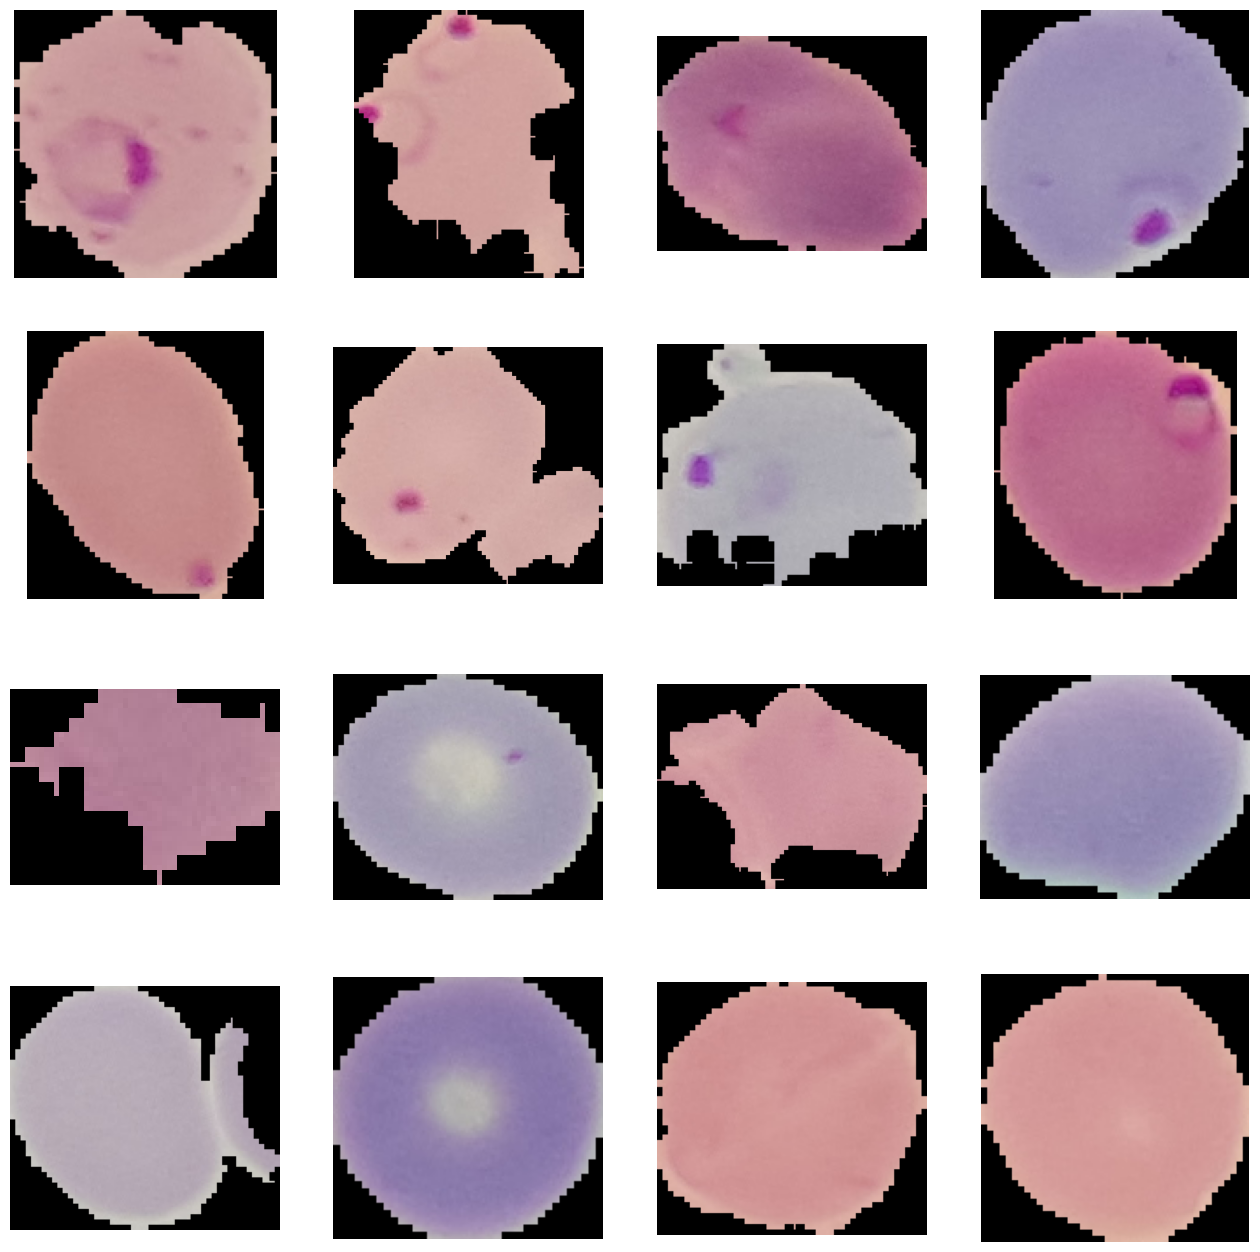

In [10]:
#Lets first see the images

train_mal_fn = os.listdir(train_mal_dir)
train_no_mal_fn = os.listdir(train_no_mal_dir)

fig = plt.figure(figsize=(16, 8))
fig.set_size_inches(16, 16)

mal_img_paths = [os.path.join(train_mal_dir, file_name) for file_name in train_mal_fn[:8]]
no_mal_img_paths = [os.path.join(train_no_mal_dir, file_name) for file_name in train_no_mal_fn[:8]]

for i, img_path in enumerate(mal_img_paths + no_mal_img_paths):
    ax = plt.subplot(4, 4, i + 1)
    ax.axis('Off')

    img = mpimg.imread(img_path)
    plt.imshow(img)

plt.show()


In [11]:
from PIL import Image
import os

shapes = set()

for img_name in os.listdir(train_mal_dir)[:50]:
    img_path = os.path.join(train_mal_dir, img_name)
    with Image.open(img_path) as img:
        shapes.add(img.size)

print("Unique image shapes:", shapes)
print ("Image Mode:", img.mode)

Unique image shapes: {(139, 139), (106, 142), (121, 100), (181, 157), (130, 118), (130, 124), (139, 160), (136, 115), (154, 136), (145, 130), (145, 136), (136, 139), (130, 157), (169, 139), (136, 154), (196, 172), (118, 115), (127, 121), (205, 184), (109, 106), (151, 139), (151, 142), (151, 148), (133, 109), (151, 151), (160, 163), (160, 169), (133, 121), (124, 124), (109, 139), (133, 130), (148, 118), (124, 133), (133, 133), (115, 100), (133, 151), (157, 148), (148, 145), (157, 154), (142, 169), (166, 160), (142, 166), (115, 127), (139, 118), (91, 160), (148, 157), (133, 163), (139, 133), (160, 226)}
Image Mode: RGB


#### **Observations & Insights:**

As we notice the size of all the images is not same, which is very crucial when working with CNNs. So we need to crop these images from the center to make sure they all have the same size. We can do this automatically , as shown below.

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(rescale=1.0 / 255.0)
test_gen = ImageDataGenerator(rescale=1.0 / 255.0)

In [13]:
train_generator = train_gen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary',
    subset='training',
    seed=SEED
)

test_generator = test_gen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary',
    shuffle= False,
    seed=SEED
)

Found 24958 images belonging to 2 classes.
Found 2600 images belonging to 2 classes.


Plotting with labels after changing the size.

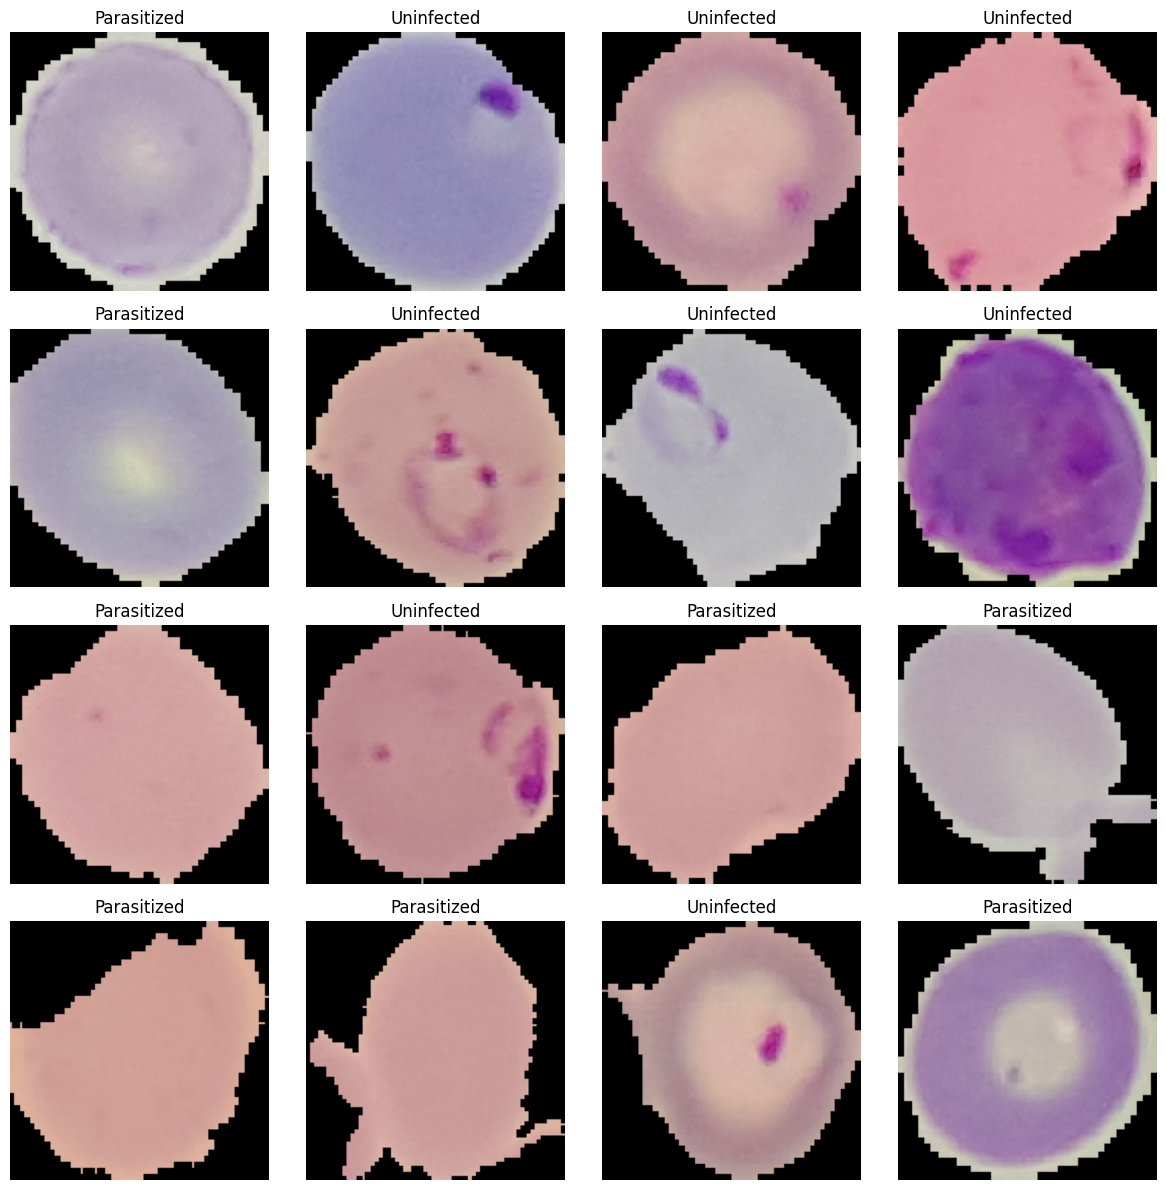

In [ ]:
images, labels = next(train_generator)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for img, label, ax in zip(images, labels, axes.flatten()):
    ax.imshow(img)
    ax.set_title("Parasitized" if label == 1 else "Uninfected")
    ax.axis("off")

plt.tight_layout()
plt.show()

#### **Observation & Insights:**
We can see that the images are now of all the same size, labelled and normalized

## **Data Exploration and Observations**

In this section, some basic info about the dataset, given.

1.   Checking the shape of train and test images
2.   Checking the shape of train and test labels
3.   Checking the minimum and maximum range of pixel values for train and test images
4. Count the number of values in both uninfected and parasitized
5. Plot to check if the data is balanced, in the case it is imbalanced we can take steps to fix the same using different popular techinques.



In [ ]:
num_train = train_generator.samples
num_test = test_generator.samples

train_images = np.zeros((num_train, 128, 128, 3), dtype='float32')
train_labels = np.zeros((num_train,), dtype='float32')

i = 0
for imgs, lbls in train_generator:
    b = imgs.shape[0]
    train_images[i:i+b] = imgs
    train_labels[i:i+b] = lbls
    i += b
    if i >= num_train:
        break

test_images = np.zeros((num_test, 128, 128, 3), dtype='float32')
test_labels = np.zeros((num_test,), dtype='float32')

i = 0
for imgs, lbls in test_generator:
    b = imgs.shape[0]
    test_images[i:i+b] = imgs
    test_labels[i:i+b] = lbls
    i += b
    if i >= num_test:
        break


In [ ]:
print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

Train images shape: (24958, 128, 128, 3)
Train labels shape: (24958,)
Test images shape: (2600, 128, 128, 3)
Test labels shape: (2600,)


#### **Observation & Insights:**
As displayed, it is noted that the train image shape implies that there are total `24958 images`, each of size `128x128 pixels` and `3 channels for RGB`.  

Similarly, it is noted that the test image shape implies that there are total `2600 images`, each of size `128x128 pixels` and `3 channels for RGB`.

In [ ]:
print("Train image min/max pixels:", train_images.min(), train_images.max())
print("Test image min/max: pixels", test_images.min(), test_images.max())

Train image min/max pixels: 0.0 1.0
Test image min/max: pixels 0.0 1.0


#### **Observation & Insights:***
**Minimum Pixel Value:** The minimum pixel value for both the training and test images is 0.0.

**Maximum Pixel Value:** The maximum pixel value for both the training and test images is 1.0.

This indicates that the image data, which typically has a pixel range of 0 to 255 for standard 8-bit images, has been preprocessed and rescaled to a range of 0.0 to 1.0, making it suitable for training a neural network.

In [ ]:
print("Train label counts:\n", pd.Series(train_labels).value_counts())
print("Test label counts:\n", pd.Series(test_labels).value_counts())

Train label counts:
 0.0    12584
1.0    12374
Name: count, dtype: int64
Test label counts:
 1.0    1300
0.0    1300
Name: count, dtype: int64


#### **Observation & Insights:**
The dataset is **highly balanced** across both training and testing sets.

Training Set: There is a near-equal distribution between `Class 0 (12,584) and Class 1 (12,374).`

Testing Set: There is a perfect *50/50 split*, with exactly `1,300 samples for each class.`

**Implications:**
*   The model is `unlikely to develop a majority-class bias`, as it will receive equal exposure to both classes during training.
*   `Accuracy will be a reliable performance metric` in this case. Unlike imbalanced datasets, where a model can achieve high accuracy by simply guessing the majority class, here a high accuracy score will truly reflect the model's ability to distinguish between classes.





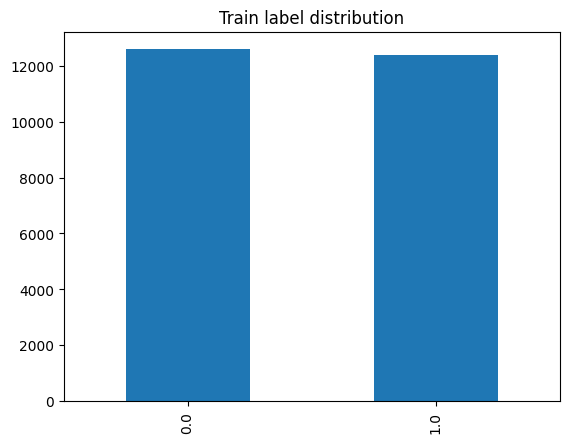

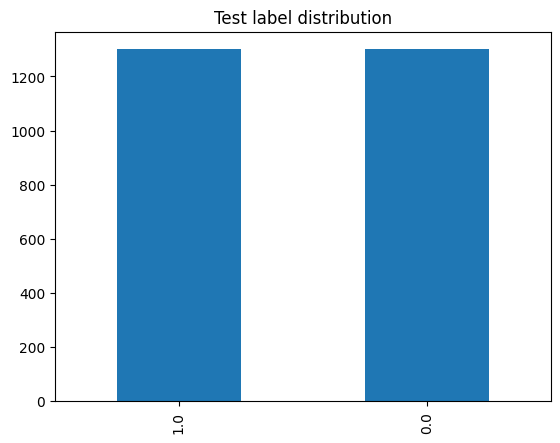

In [ ]:
pd.Series(train_labels).value_counts().plot(kind='bar', title='Train label distribution')
plt.show()

pd.Series(test_labels).value_counts().plot(kind='bar', title='Test label distribution')
plt.show()

#### **Observation & Insights**
The plot is simply reflecting the above mentioned attributes visually as well, thereby confirming the insights and observations.

In [ ]:
# Function to find the mean
def find_mean_img(full_mat, title):

    # Calculate the average
    mean_img = np.mean(full_mat, axis = 0)[0]

    # Reshape it back to a matrix
    plt.imshow(mean_img)

    plt.title(f'Average {title}')

    plt.axis('off')

    plt.show()

    return mean_img

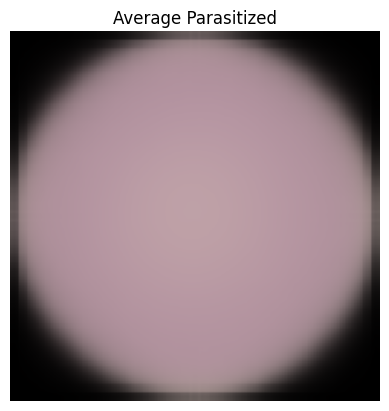

In [ ]:
# If the label = 1 then the image is parasitised and if the label = 0 then the image is uninfected
parasitized_data = []  # Create a list to store the parasitized data

for img, label in zip(train_images, train_labels):

        if label == 1:

              parasitized_data.append([img])

parasitized_mean = find_mean_img(np.array(parasitized_data), 'Parasitized')   # find the mean

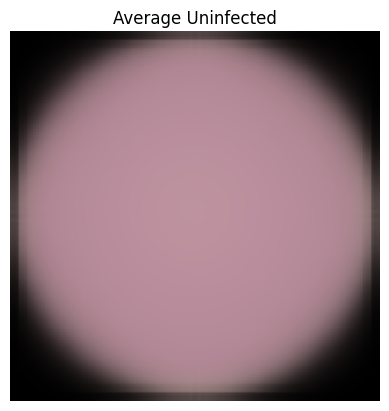

In [ ]:
# If the label = 1 then the image is parasitised and if the label = 0 then the image is uninfected
no_mal_data = []

for img, label in zip(train_images, train_labels):

        if label == 0:

              no_mal_data.append([img])

no_mal_mean = find_mean_img(np.array(no_mal_data), 'Uninfected')   # find the mean

Note#1: Gaussian blurring was not applied as a standard preprocessing step, as malaria parasite detection relies on fine-grained texture and morphological features that may be suppressed by smoothing operations. Since convolutional neural networks are inherently capable of learning noise-robust representations, blurring was instead considered only as a mild data augmentation technique to simulate focus variability in microscopy images.

Note #2: Since this is a binary classification problem, labels are kept in binary format (0/1) and a sigmoid activation with binary cross-entropy loss is used.

## **Model Building**
Now that the data preprocessing and exploration is done, next step is to build various Convolutional Neural Network (CNN) models to see the performance of the models and better choose the one deploying.

To acheive fairness in different models' comparison, it is carefully ensured that all models were **trained under identical experimental conditions.**

These include:
1.   Same train/val split
2.   Same optimizer
3. Same BATCH_SIZE
4. Same IMAGE_SIZE
5. Same NO_OF_EPOCHS
6. Same Loss Function = binary_crossentropy
7. Same Callbacks Logic
    * Patience = 5
    * Monitor = val_loss (Early Stopping, when applied)
    * Monitor = val_accuracy (ModelCheckpoint, when applied)


**The improvement in the model is noted via:**
1. Architecture depth
2. Number of filters
3. Activation functions
4. Batch Normalization
5. Data augmentation
6. Transfer learning vs scratch
7. Using different pretrained models


> **Base Model:**

In [14]:
train_val_gen = ImageDataGenerator(rescale=1.0 / 255.0,validation_split=0.2)

In [15]:
# rewriting for validation
train_generator = train_val_gen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary',
    subset='training',
    seed=SEED
)

val_generator = train_val_gen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary',
    subset='validation',
    seed=SEED
)

Found 19967 images belonging to 2 classes.
Found 4991 images belonging to 2 classes.


In [16]:
from tensorflow.keras import backend
backend.clear_session()

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

In [ ]:
# Build base CNN model
base_model = Sequential([

    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3), padding = 'same'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu',padding = 'same'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu',padding = 'same'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile the model
base_model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
history_base_model = base_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

Epoch 1/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 466s 373ms/step - accuracy: 0.6917 - loss: 0.5754 - val_accuracy: 0.9082 - val_loss: 0.2006
Epoch 2/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 463s 371ms/step - accuracy: 0.9418 - loss: 0.1643 - val_accuracy: 0.9293 - val_loss: 0.1760
Epoch 3/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 465s 373ms/step - accuracy: 0.9617 - loss: 0.1154 - val_accuracy: 0.9527 - val_loss: 0.1237
Epoch 4/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 462s 370ms/step - accuracy: 0.9707 - loss: 0.0888 - val_accuracy: 0.9449 - val_loss: 0.1534
Epoch 5/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 460s 369ms/step - accuracy: 0.9758 - loss: 0.0738 - val_accuracy: 0.9441 - val_loss: 0.1473
Epoch 6/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 463s 371ms/step - accuracy: 0.9820 - loss: 0.0580 - val_accuracy: 0.9597 - val_loss: 0.1069
Epoch 7/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 475s 381ms/step - accuracy: 0.9802 - loss: 0.0599 - val_accuracy: 0.9553 - val_loss: 0.1167
Epoch 8/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 520s 417ms/step - ac

In [ ]:
base_model.evaluate(test_generator)

163/163 ━━━━━━━━━━━━━━━━━━━━ 17s 106ms/step - accuracy: 0.9651 - loss: 0.1318


[0.13860481977462769, 0.9649999737739563]

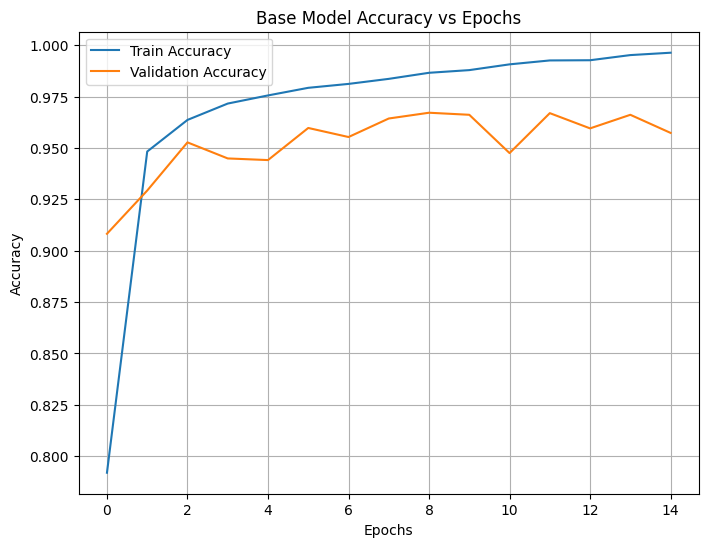

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(history_base_model.history['accuracy'], label='Train Accuracy')
plt.plot(history_base_model.history['val_accuracy'], label='Validation Accuracy')

plt.title('Base Model Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Reset generator to avoid shuffling issues
test_generator.reset()

# Predict probabilities
y_pred_prob = base_model.predict(test_generator)

# Convert probabilities to class labels (0 or 1)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

# True labels
y_true = test_generator.classes

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


163/163 ━━━━━━━━━━━━━━━━━━━━ 18s 107ms/step


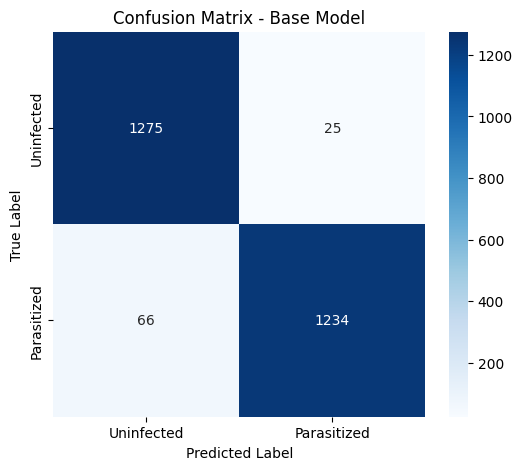

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Uninfected', 'Parasitized'],
            yticklabels=['Uninfected', 'Parasitized'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Base Model')
plt.show()

In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=['Uninfected', 'Parasitized']
))

              precision    recall  f1-score   support

  Uninfected       0.95      0.98      0.97      1300
 Parasitized       0.98      0.95      0.96      1300

    accuracy                           0.96      2600
   macro avg       0.97      0.96      0.96      2600
weighted avg       0.97      0.96      0.96      2600





> **Model 1**


In [ ]:
from tensorflow.keras import backend
backend.clear_session()

In [ ]:
from tensorflow.keras.layers import BatchNormalization, LeakyReLU

In [ ]:
model_1 = Sequential([

    Conv2D(32, (3, 3), padding='same', input_shape=(128, 128, 3)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(32, (3, 3), padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

In [ ]:
mc = ModelCheckpoint('model_1_best.h5', monitor='val_accuracy', mode= 'max', save_best_only=True, verbose=1)

In [ ]:
model_1.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history_model_1 = model_1.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[mc]
)

Epoch 1/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.8158 - loss: 0.3932
Epoch 1: val_accuracy improved from -inf to 0.94931, saving model to model_1_best.h5


1248/1248 ━━━━━━━━━━━━━━━━━━━━ 466s 374ms/step - accuracy: 0.8159 - loss: 0.3931 - val_accuracy: 0.9493 - val_loss: 0.1339
Epoch 2/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.9630 - loss: 0.1147
Epoch 2: val_accuracy improved from 0.94931 to 0.96674, saving model to model_1_best.h5


1248/1248 ━━━━━━━━━━━━━━━━━━━━ 521s 418ms/step - accuracy: 0.9630 - loss: 0.1147 - val_accuracy: 0.9667 - val_loss: 0.0911
Epoch 3/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.9737 - loss: 0.0879
Epoch 3: val_accuracy did not improve from 0.96674
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 516s 413ms/step - accuracy: 0.9737 - loss: 0.0879 - val_accuracy: 0.9611 - val_loss: 0.1037
Epoch 4/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.9776 - loss: 0.0691
Epoch 4: val_accuracy improved from 0.96674 to 0.96975, saving model to model_1_best.h5


1248/1248 ━━━━━━━━━━━━━━━━━━━━ 490s 393ms/step - accuracy: 0.9776 - loss: 0.0691 - val_accuracy: 0.9697 - val_loss: 0.0768
Epoch 5/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.9792 - loss: 0.0630
Epoch 5: val_accuracy improved from 0.96975 to 0.97415, saving model to model_1_best.h5


1248/1248 ━━━━━━━━━━━━━━━━━━━━ 470s 377ms/step - accuracy: 0.9792 - loss: 0.0630 - val_accuracy: 0.9742 - val_loss: 0.0673
Epoch 6/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.9833 - loss: 0.0546
Epoch 6: val_accuracy did not improve from 0.97415
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 476s 381ms/step - accuracy: 0.9833 - loss: 0.0546 - val_accuracy: 0.9709 - val_loss: 0.0718
Epoch 7/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.9835 - loss: 0.0502
Epoch 7: val_accuracy did not improve from 0.97415
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 472s 378ms/step - accuracy: 0.9835 - loss: 0.0502 - val_accuracy: 0.9724 - val_loss: 0.0702
Epoch 8/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.9841 - loss: 0.0471
Epoch 8: val_accuracy did not improve from 0.97415
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 492s 394ms/step - accuracy: 0.9841 - loss: 0.0471 - val_accuracy: 0.9685 - val_loss: 0.0920
Epoch 9/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.9872 - loss: 0.

1248/1248 ━━━━━━━━━━━━━━━━━━━━ 469s 376ms/step - accuracy: 0.9872 - loss: 0.0399 - val_accuracy: 0.9770 - val_loss: 0.0694
Epoch 10/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.9872 - loss: 0.0373
Epoch 10: val_accuracy did not improve from 0.97696
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 465s 373ms/step - accuracy: 0.9872 - loss: 0.0373 - val_accuracy: 0.9673 - val_loss: 0.0944
Epoch 11/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.9903 - loss: 0.0290
Epoch 11: val_accuracy did not improve from 0.97696
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 462s 370ms/step - accuracy: 0.9903 - loss: 0.0290 - val_accuracy: 0.9719 - val_loss: 0.0797
Epoch 12/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.9910 - loss: 0.0268
Epoch 12: val_accuracy did not improve from 0.97696
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 469s 376ms/step - accuracy: 0.9910 - loss: 0.0268 - val_accuracy: 0.9754 - val_loss: 0.0741
Epoch 13/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.9908 - l

1248/1248 ━━━━━━━━━━━━━━━━━━━━ 475s 381ms/step - accuracy: 0.9910 - loss: 0.0284 - val_accuracy: 0.9780 - val_loss: 0.0716
Epoch 15/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.9934 - loss: 0.0213
Epoch 15: val_accuracy did not improve from 0.97796
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 471s 378ms/step - accuracy: 0.9934 - loss: 0.0213 - val_accuracy: 0.9760 - val_loss: 0.0775


In [ ]:
from tensorflow.keras.models import load_model
model_1= load_model("model_1_best.h5")
model_1.evaluate(test_generator)

163/163 ━━━━━━━━━━━━━━━━━━━━ 14s 85ms/step - accuracy: 0.9835 - loss: 0.0417


[0.04508843645453453, 0.9842307567596436]

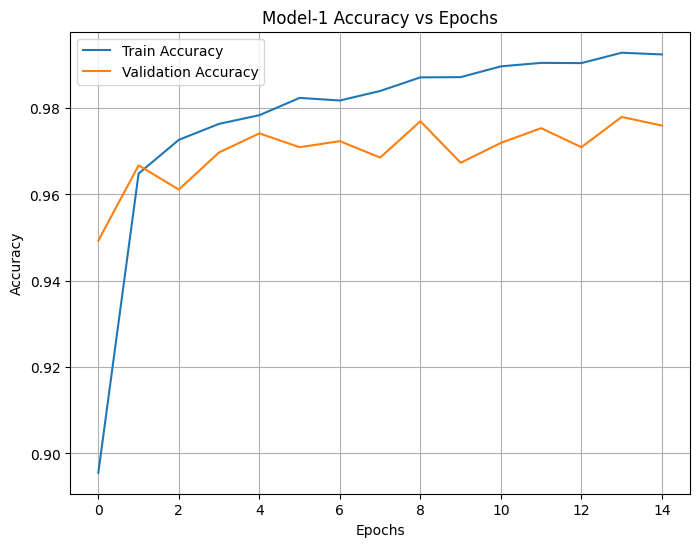

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(history_model_1.history['accuracy'], label='Train Accuracy')
plt.plot(history_model_1.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model-1 Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
test_generator.reset()

y_pred_prob_1 = model_1.predict(test_generator)
y_pred_1 = (y_pred_prob_1 > 0.5).astype(int).ravel()

y_true = test_generator.classes

163/163 ━━━━━━━━━━━━━━━━━━━━ 14s 83ms/step


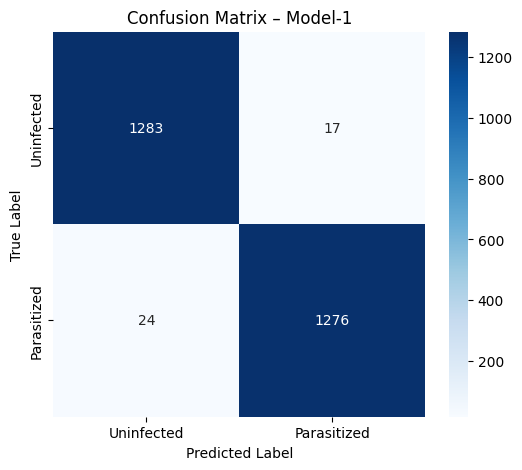

In [ ]:
cm_1 = confusion_matrix(y_true, y_pred_1)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_1,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Uninfected', 'Parasitized'],
    yticklabels=['Uninfected', 'Parasitized']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix – Model-1')
plt.show()

In [ ]:
print(classification_report(
    y_true,
    y_pred_1,
    target_names=['Uninfected', 'Parasitized']
))

              precision    recall  f1-score   support

  Uninfected       0.98      0.99      0.98      1300
 Parasitized       0.99      0.98      0.98      1300

    accuracy                           0.98      2600
   macro avg       0.98      0.98      0.98      2600
weighted avg       0.98      0.98      0.98      2600



> **Model 2**

Data Augmentation:

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.2,
    horizontal_flip=True,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1
)

val_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.2
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary',
    subset='training',
    seed=SEED
)
val_generator = val_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary',
    subset='validation',
    seed=SEED
)

Found 19967 images belonging to 2 classes.
Found 4991 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.layers import AveragePooling2D, Concatenate,Input
from tensorflow.keras.models import Model

input_layer = Input(shape=(128, 128, 3))

# ---- Block 1 ----
x = Conv2D(32, (3,3), padding='same')(input_layer)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.1)(x)

max_p = MaxPooling2D(pool_size=(2,2))(x)
avg_p = AveragePooling2D(pool_size=(2,2))(x)
x = Concatenate()([max_p, avg_p])

# ---- Block 2 ----
x = Conv2D(64, (3,3), padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.1)(x)

max_p = MaxPooling2D(pool_size=(2,2))(x)
avg_p = AveragePooling2D(pool_size=(2,2))(x)
x = Concatenate()([max_p, avg_p])

# ---- Block 3 ----
x = Conv2D(128, (3,3), padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.1)(x)

max_p = MaxPooling2D(pool_size=(2,2))(x)
avg_p = AveragePooling2D(pool_size=(2,2))(x)
x = Concatenate()([max_p, avg_p])

# ---- Classifier ----
x = Flatten()(x)
x = Dense(128)(x)
x = LeakyReLU(alpha=0.1)(x)

output = Dense(1, activation='sigmoid')(x)

model_2 = Model(inputs=input_layer, outputs=output)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [ ]:
model_2.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
es= EarlyStopping(monitor='val_loss', patience=5, mode= 'min', restore_best_weights=True, verbose=1)
mc= ModelCheckpoint('model_2_best.h5', monitor='val_accuracy', mode= 'max', save_best_only=True, verbose=1)

In [ ]:
history_model_2 = model_2.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[es, mc]
)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 845ms/step - accuracy: 0.7622 - loss: 0.5688
Epoch 1: val_accuracy improved from -inf to 0.88700, saving model to model_2_best.h5


1248/1248 ━━━━━━━━━━━━━━━━━━━━ 1120s 896ms/step - accuracy: 0.7623 - loss: 0.5686 - val_accuracy: 0.8870 - val_loss: 0.6046
Epoch 2/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 913ms/step - accuracy: 0.9385 - loss: 0.1896
Epoch 2: val_accuracy improved from 0.88700 to 0.93428, saving model to model_2_best.h5


1248/1248 ━━━━━━━━━━━━━━━━━━━━ 1245s 962ms/step - accuracy: 0.9385 - loss: 0.1896 - val_accuracy: 0.9343 - val_loss: 0.2105
Epoch 3/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 926ms/step - accuracy: 0.9548 - loss: 0.1435
Epoch 3: val_accuracy improved from 0.93428 to 0.95312, saving model to model_2_best.h5


1248/1248 ━━━━━━━━━━━━━━━━━━━━ 1213s 972ms/step - accuracy: 0.9548 - loss: 0.1435 - val_accuracy: 0.9531 - val_loss: 0.1424
Epoch 4/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 889ms/step - accuracy: 0.9578 - loss: 0.1354
Epoch 4: val_accuracy improved from 0.95312 to 0.95913, saving model to model_2_best.h5


1248/1248 ━━━━━━━━━━━━━━━━━━━━ 1178s 937ms/step - accuracy: 0.9578 - loss: 0.1354 - val_accuracy: 0.9591 - val_loss: 0.1277
Epoch 5/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 851ms/step - accuracy: 0.9534 - loss: 0.1498
Epoch 5: val_accuracy improved from 0.95913 to 0.96594, saving model to model_2_best.h5


1248/1248 ━━━━━━━━━━━━━━━━━━━━ 1121s 898ms/step - accuracy: 0.9535 - loss: 0.1498 - val_accuracy: 0.9659 - val_loss: 0.1001
Epoch 6/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 842ms/step - accuracy: 0.9617 - loss: 0.1275
Epoch 6: val_accuracy did not improve from 0.96594
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 1110s 889ms/step - accuracy: 0.9617 - loss: 0.1275 - val_accuracy: 0.9591 - val_loss: 0.1463
Epoch 7/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 849ms/step - accuracy: 0.9669 - loss: 0.1103
Epoch 7: val_accuracy did not improve from 0.96594
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 1118s 896ms/step - accuracy: 0.9669 - loss: 0.1103 - val_accuracy: 0.9389 - val_loss: 0.2371
Epoch 8/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 870ms/step - accuracy: 0.9650 - loss: 0.1091
Epoch 8: val_accuracy improved from 0.96594 to 0.97155, saving model to model_2_best.h5


1248/1248 ━━━━━━━━━━━━━━━━━━━━ 1146s 919ms/step - accuracy: 0.9650 - loss: 0.1091 - val_accuracy: 0.9715 - val_loss: 0.0968
Epoch 9/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 840ms/step - accuracy: 0.9672 - loss: 0.1067
Epoch 9: val_accuracy did not improve from 0.97155
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 1107s 887ms/step - accuracy: 0.9672 - loss: 0.1067 - val_accuracy: 0.9701 - val_loss: 0.0846
Epoch 10/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 839ms/step - accuracy: 0.9708 - loss: 0.1017
Epoch 10: val_accuracy did not improve from 0.97155
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 1106s 886ms/step - accuracy: 0.9708 - loss: 0.1017 - val_accuracy: 0.9641 - val_loss: 0.1006
Epoch 11/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 848ms/step - accuracy: 0.9671 - loss: 0.0971
Epoch 11: val_accuracy did not improve from 0.97155
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 1118s 896ms/step - accuracy: 0.9671 - loss: 0.0971 - val_accuracy: 0.9661 - val_loss: 0.0908
Epoch 12/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 842ms/step - accuracy: 0.9696 -

In [ ]:
model_2= load_model("model_2_best.h5")
model_2.evaluate(test_generator)

163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 205ms/step - accuracy: 0.9792 - loss: 0.0607


[0.11741364747285843, 0.9730769395828247]

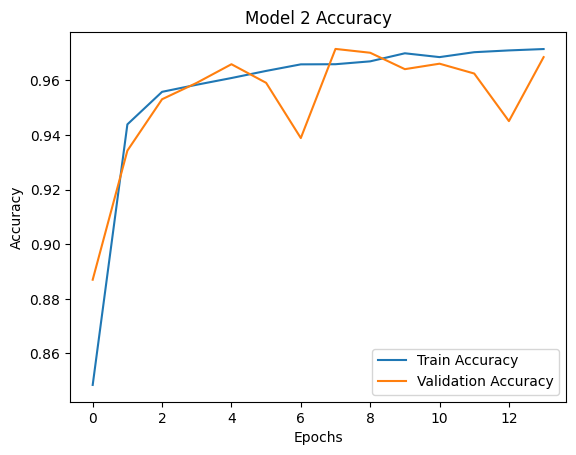

In [ ]:
plt.plot(history_model_2.history['accuracy'], label='Train Accuracy')
plt.plot(history_model_2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 2 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# Predictions
y_pred_prob = model_2.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int)

# True labels
y_true = test_generator.classes

163/163 ━━━━━━━━━━━━━━━━━━━━ 38s 233ms/step


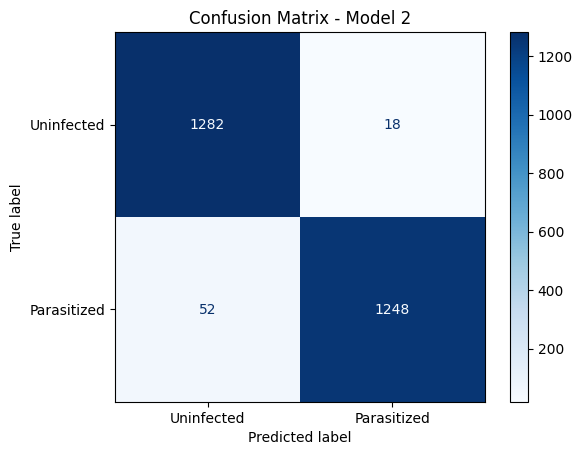

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Uninfected', 'Parasitized']
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Model 2')
plt.show()

In [ ]:
print(classification_report(
    y_true,
    y_pred_1,
    target_names=['Uninfected', 'Parasitized']
))

              precision    recall  f1-score   support

  Uninfected       0.98      0.99      0.98      1300
 Parasitized       0.99      0.98      0.98      1300

    accuracy                           0.98      2600
   macro avg       0.98      0.98      0.98      2600
weighted avg       0.98      0.98      0.98      2600



> **VGG-16 Pre-trained Model**

In [18]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dropout, Dense, Flatten

vgg_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)
for layer in vgg_base.layers:
    layer.trainable = False

x = vgg_base.output
x = Flatten()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(1, activation='sigmoid')(x)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [20]:
from tensorflow.keras.models import Model

In [21]:
model_vgg16 = Model(inputs=vgg_base.input, outputs=output)

In [ ]:
from tensorflow.keras.optimizers import Adam

In [22]:
model_vgg16.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

In [23]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [24]:
es= EarlyStopping(monitor='val_loss', patience=5, mode= 'min', restore_best_weights=True, verbose=1)
mc= ModelCheckpoint('model_2_best.h5', monitor='val_accuracy', mode= 'max', save_best_only=True, verbose=1)

In [ ]:
history_vgg16 = model_vgg16.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[es, mc]
)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8128 - loss: 0.3931
Epoch 1: val_accuracy improved from -inf to 0.91244, saving model to model_2_best.h5


1248/1248 ━━━━━━━━━━━━━━━━━━━━ 1564s 1s/step - accuracy: 0.8128 - loss: 0.3930 - val_accuracy: 0.9124 - val_loss: 0.2139
Epoch 2/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9355 - loss: 0.1767
Epoch 2: val_accuracy improved from 0.91244 to 0.93649, saving model to model_2_best.h5


1248/1248 ━━━━━━━━━━━━━━━━━━━━ 1562s 1s/step - accuracy: 0.9355 - loss: 0.1767 - val_accuracy: 0.9365 - val_loss: 0.1664
Epoch 3/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9482 - loss: 0.1445
Epoch 3: val_accuracy improved from 0.93649 to 0.94089, saving model to model_2_best.h5


1248/1248 ━━━━━━━━━━━━━━━━━━━━ 1562s 1s/step - accuracy: 0.9482 - loss: 0.1445 - val_accuracy: 0.9409 - val_loss: 0.1568
Epoch 4/15
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9550 - loss: 0.1321
Epoch 4: val_accuracy improved from 0.94089 to 0.94570, saving model to model_2_best.h5


1248/1248 ━━━━━━━━━━━━━━━━━━━━ 1560s 1s/step - accuracy: 0.9550 - loss: 0.1321 - val_accuracy: 0.9457 - val_loss: 0.1496
Epoch 5/15
1031/1248 ━━━━━━━━━━━━━━━━━━━━ 3:37 1s/step - accuracy: 0.9570 - loss: 0.1282

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(history_vgg16.history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg16.history['val_accuracy'], label='Validation Accuracy')

plt.title('VGG16 Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_pred_prob = model_vgg16.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int)

y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Uninfected', 'Parasitized']
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix - VGG16')
plt.show()